<a href="https://colab.research.google.com/github/benjaminqq-12/ISWN/blob/main/EA2_1_630454_EjemploRegresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo de regresión lineal

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ymeza@ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece la explicación de la creación de un modelo predictivo para una variable continua.

Mantiene el uso de pipeline como buena práctica de la industria.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [258]:
!wget https://raw.githubusercontent.com/benjaminqq-12/Inteligencia-Artificial-2026-2/refs/heads/main/E1-EDA/lab_costos_envio.csv

--2026-09-25 17:26:37--  https://raw.githubusercontent.com/benjaminqq-12/Inteligencia-Artificial-2026-2/refs/heads/main/E1-EDA/lab_costos_envio.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 378822 (370K) [text/plain]
Saving to: ‘lab_costos_envio.csv.1’

lab_costos_envio.cs 100%[===================>] 369.94K  --.-KB/s    in 0.1s    

2026-09-25 17:26:38 (3.40 MB/s) - ‘lab_costos_envio.csv.1’ saved [378822/378822]



In [259]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [260]:
data = pd.read_csv('lab_costos_envio.csv')
data.head()

,id_paquete,peso_kg,distancia_km,tipo_servicio,es_fragil,costo_envio
0,PKG-0001,25.98,671.4,Express,No,123.79
1,PKG-0002,8.90,225.7,Estandar,No,39.34
2,PKG-0003,2.66,473.6,Estandar,Si,59.34
3,PKG-0004,23.02,89.3,Estandar,No,56.90
4,PKG-0005,13.86,68.2,Estandar,No,40.89


## Objetivo

Predecir el precio de la vivienda, considerando `algunas` de sus características

# Fase 2 - Entendimiento de los datos

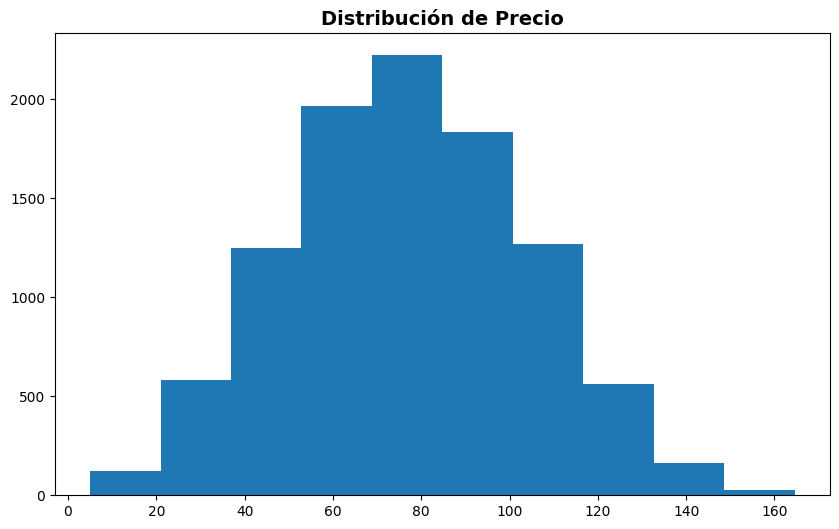

In [261]:
data.costo_envio.hist(bins=10, figsize=(10,6), grid=False)
plt.title("Distribución de Precio", fontsize=14, fontweight="bold")
plt.show()

## Detección de inconsistencias

In [262]:
# Detectar inconsistencias
inconsistentes = data[(data["peso_kg"] <= 0) | (data["distancia_km"] <= 0) | (data["costo_envio"] < 0)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,id_paquete,peso_kg,distancia_km,tipo_servicio,es_fragil,costo_envio


## Detección de nulos

In [263]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_paquete     10000 non-null  object 
 1   peso_kg        9394 non-null   float64
 2   distancia_km   9542 non-null   float64
 3   tipo_servicio  10000 non-null  object 
 4   es_fragil      10000 non-null  object 
 5   costo_envio    10000 non-null  float64
dtypes: float64(3), object(3)
memory usage: 468.9+ KB


## Detección de valores atípicos

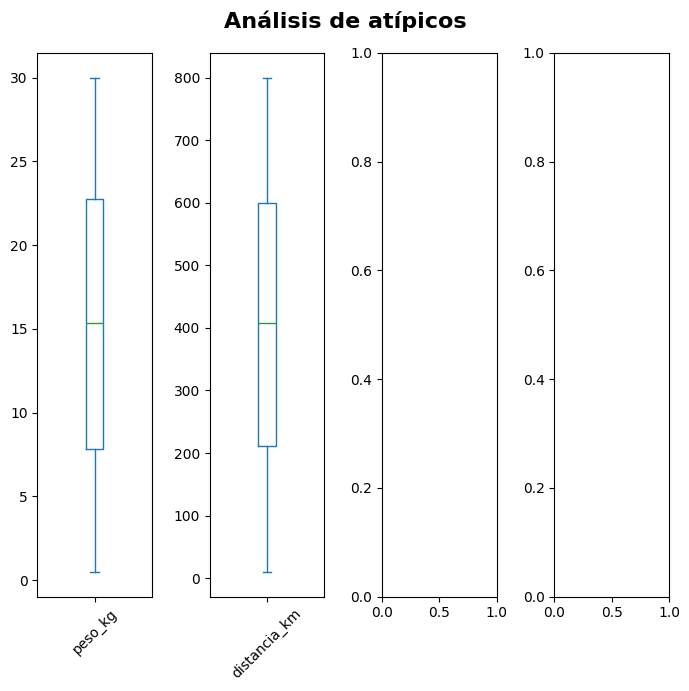

In [264]:
revision_atipicos = ['peso_kg','distancia_km']
fig, axes = plt.subplots(1, 4, figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Detección de duplicados

In [265]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(0)

In [266]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)]

,id_paquete,peso_kg,distancia_km,tipo_servicio,es_fragil,costo_envio


# Fase 3 - Preparación de datos

**✅ Automatización de fases 3 y 4**

Las fases de preparación y modelamiento se van a automatizar a través del uso de un ´pipeline´.

Ventajas de usar esta técnica:

+ Se puede encadenar imputación de nulos, codificación de variables categóricas y el modelo.

+ Permite hacer el mismo preprocesamiento en train y test sin errores.

+ Se vuelve reutilizable para producción o para predecir sobre nuevos datos.

Posible desventaja:

+ Todo queda encapsulado y no se ve fácilmente cómo quedaron los datos después de cada transformación.

In [267]:
target = "costo_envio"

In [268]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [269]:
def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

In [270]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [271]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
  """
  Ingeniería de características avanzada para capturar tarifas por tipo de servicio
  """
  def __init__(self):
    pass

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()

    # 1. Interacción física base
    X["peso_por_distancia"] = X["peso_kg"] * X["distancia_km"]
    X["raiz_peso_distancia"] = np.sqrt(X["peso_kg"] * X["distancia_km"] + 1)

    # 2. Factor multiplicador según el tipo de servicio (tarifa base aproximada)
    servicio_map = {"Estandar": 1.0, "Express": 1.5, "Mismo_Dia": 2.0}
    factor_servicio = X["tipo_servicio"].map(servicio_map).fillna(1.0)

    # 3. Interacciones avanzadas que representan la tarifa real de envíos
    X["peso_por_servicio"] = X["peso_kg"] * factor_servicio
    X["distancia_por_servicio"] = X["distancia_km"] * factor_servicio
    X["trabajo_por_servicio"] = X["peso_por_distancia"] * factor_servicio

    return X

In [272]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

In [273]:
# Preprocesamiento numérico: imputación con media + estandarización (Desactivamos Winsorizer con límites 0.0)
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.0, 0.0))),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

## Evaluación de las mejores variables `predictoras`

In [274]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,costo_envio
costo_envio,1.000000
distancia_km,0.683328
peso_kg,0.575361


In [275]:
data.groupby("tipo_servicio")[target].mean().sort_values()

,costo_envio
tipo_servicio,
Estandar,68.117564
Express,80.369926
Mismo_Dia,98.995030


In [276]:
encoder = OneHotEncoder(sparse_output=False)
ts_encoded = encoder.fit_transform(data[["tipo_servicio"]])

data_ohe = pd.DataFrame(ts_encoded, columns=encoder.get_feature_names_out())

data_corr = pd.concat([data, data_ohe], axis=1)

data_corr.corr(numeric_only=True)[target]

,costo_envio
peso_kg,0.575361
distancia_km,0.683328
costo_envio,1.000000
tipo_servicio_Estandar,-0.330880
tipo_servicio_Express,0.088727
tipo_servicio_Mismo_Dia,0.342883


In [277]:
data_corr.corr(numeric_only=True)[target]

,costo_envio
peso_kg,0.575361
distancia_km,0.683328
costo_envio,1.000000
tipo_servicio_Estandar,-0.330880
tipo_servicio_Express,0.088727
tipo_servicio_Mismo_Dia,0.342883


**Importante**

De la tabla anterior se obtienen las mejores `variables predictoras` para el modelo.

# Fase 4 - Modelamiento

In [278]:
# Variables
features_num = ["peso_kg", "distancia_km"]
features_cat = ["tipo_servicio", "es_fragil"]
target = "costo_envio"

X = data[features_num + features_cat]
y = data[target]

In [279]:
# Agregamos las variables numéricas interactivas al preprocesador
features_num_eng = features_num + [
    "peso_por_distancia",
    "raiz_peso_distancia",
    "peso_por_servicio",
    "distancia_por_servicio",
    "trabajo_por_servicio"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num_eng),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)

In [280]:
# Re-creamos el pipeline final y lo entrenamos
modelo = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("feature_engineering", FeatureEngineering()),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.999)),
    ("modelo", LinearRegression())
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=29)

# Entrenamiento del modelo
modelo.fit(X_train, y_train)

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x7ee39cc4dbc0>,
                                     kw_args={'drop': False})),
                ('feature_engineering', FeatureEngineering()),
                ('preprocesador',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer(limits=(0.0,
                                                                                      0.0))),
                                                                  ('imputer'...
                                                                                   'raiz_peso_distancia',
                                                                                   'peso_por_servicio',
                                                                                   'distancia_por_servicio',
                                                                                   'trabajo_por_servicio']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('onehot',
                                                                                                   OneHotEncoder(drop='first',
                                                                                                                 handle_unknown='ignore'))]),
                                                                                  ['tipo_servicio',
                                                                                   'es_fragil'])]))),
                ('colinealidad', CorrelationFilter(threshold=0.999)),
                ('modelo', LinearRegression())])

In [281]:
# Predicciones con las nuevas variables interactivas de servicio
y_pred = modelo.predict(X_test)

# Evaluación de las nuevas métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Nuevas Métricas del modelo ---")
print(f"{'R2':<6}: {r2:.3f}")
print(f"{'MAE':<6}: {mae:.3f}")


--- Nuevas Métricas del modelo ---
R2    : 0.944
MAE   : 4.063


In [282]:
print(f"{'R2 en test':<20}: {r2:.3f}")
y_pred_train = modelo.predict(X_train)
print(f"{'R2 en train':<20}: {r2_score(y_train, y_pred_train):.3f}")

R2 en test          : 0.944
R2 en train         : 0.944


In [283]:
y_pred.round(2)

array([ 80.35, 120.35,  97.8 , ...,  23.31,  62.03, 112.  ])

In [284]:
nombres = preprocessor.get_feature_names_out()
nombres

array(['num__peso_kg', 'num__distancia_km', 'num__peso_por_distancia',
       'num__raiz_peso_distancia', 'num__peso_por_servicio',
       'num__distancia_por_servicio', 'num__trabajo_por_servicio',
       'cat__tipo_servicio_Express', 'cat__tipo_servicio_Mismo_Dia',
       'cat__es_fragil_Si'], dtype=object)

In [285]:
# Variables que fueron eliminadas por presentar colinealidad
modelo.named_steps["colinealidad"].columns_to_drop_

[]

In [286]:
# Variables con las cuales fue entrenado el modelo
modelo.named_steps["conversion"].feature_names_

array(['num__peso_kg', 'num__distancia_km', 'num__peso_por_distancia',
       'num__raiz_peso_distancia', 'num__peso_por_servicio',
       'num__distancia_por_servicio', 'num__trabajo_por_servicio',
       'cat__tipo_servicio_Express', 'cat__tipo_servicio_Mismo_Dia',
       'cat__es_fragil_Si'], dtype=object)

In [287]:
# Predicción de costo de envío (con datos COMPLETAMENTE nuevos)
nuevo = pd.DataFrame([
    {
        "peso_kg": 2071.0,
        "distancia_km": 1462.0,
        "tipo_servicio": "Estandar",
        "es_fragil": "No"
    }
])

pred = modelo.predict(nuevo)
pred.round(2)

array([3917.59])

In [288]:
# Predicción con datos totalmente nuevos
X_data = pd.DataFrame({
    "peso_kg": [10.0, 153.0, 250.0],
    "distancia_km": [5840, 32, 400],
    "tipo_servicio": ["Express", "Estandar", "Express"],
    "es_fragil": ["No", "Si", "No"]
})
prediccion = modelo.predict(X_data)
prediccion.round(2)

array([502.71, 291.53, 496.17])

# Validación de restricciones mínimas



Umbrales de evaluación